# Langchain

In [ ]:
import os 
from dotenv import load_dotenv

load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")



In [9]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")

llm_msg =llm.invoke("Say Jai Mata Di , Sache Dabara Wala Mata di Jai")
print(llm_msg.content)

<think>
Okay, the user is asking me to say "Jai Mata Di" and "Sache Dabara Wala Mata di Jai." Let me break this down. "Jai Mata Di" is a common phrase of devotion in Punjab, especially among Sikhs, where "Mata" refers to the mother goddess or a revered mother figure. The phrase is often used to express respect and devotion.

Now, the second part is "Sache Dabara Wala Mata di Jai." "Sache Dabara" translates to "True and the First," which is a reference to the concept of truth and the origin. "Wala" means "of" or "related to," so putting it together, it's saying "Victory to the Mother of True Origin." This might be a specific reference to a deity or a concept in Sikh philosophy, emphasizing the mother as the source of truth.

I need to make sure I understand the context correctly. The user might be looking for a response that echoes these phrases, possibly for a religious or cultural reason. They might be part of a community that uses these terms in prayers, songs, or rituals. I should a


# Messages 
Messages are the actual conversation format that chat models use 


- HumanMessage : User Speaks
- AIMessage : Model Speaks 
- SystemMessage : Model rules


In [13]:
from langchain_core.messages import HumanMessage , AIMessage , SystemMessage
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")



message = [
    HumanMessage(content="My name is Divyansh"),
    AIMessage(content="Nice to meet you "),
    HumanMessage(content="What's my name ?"),
    SystemMessage(content="act as a personal assistant")
]

res = llm.invoke(message)
print(res.content)

<think>
Okay, the user asked, "What's my name?" Let me check the conversation history. The user introduced themselves as Divyansh earlier. I need to confirm that the name hasn't changed.

First, I should recall the previous messages. The user said their name is Divyansh, and I acknowledged it. Now they're asking again. Maybe they want to verify if I remember correctly, or perhaps they're testing my memory. 

I should respond with certainty, stating their name clearly. Maybe add a friendly touch to make it sound natural. Also, offer assistance in case they need anything else. Keep it concise and polite.
</think>

Your name is **Divyansh**. 😊 Let me know if there's anything I can assist you with!


# Prompt Templates 

hardcore prompts are bad 

In [ ]:
from langchain_core.prompts import PromptTemplate

prompt = PromptTemplate.from_template(
    "Explain {topic} in simple words"
)

res = prompt.invoke({
    "topic":"Python"
})




# Streaming 

- you can see the text generation real time 

In [21]:
from langchain_groq import ChatGroq

llm= ChatGroq(model="qwen/qwen3-32b")

for c in llm.stream("Explain Vasuki Indicus?"):
    print(c.content.center)

<built-in method center of str object at 0x1039db630>
<built-in method center of str object at 0x1142df240>
<built-in method center of str object at 0x1039e5748>
<built-in method center of str object at 0x1142de700>
<built-in method center of str object at 0x1039e5da8>
<built-in method center of str object at 0x1142de790>
<built-in method center of str object at 0x1142de730>
<built-in method center of str object at 0x1142df120>
<built-in method center of str object at 0x1142df180>
<built-in method center of str object at 0x11479c9b0>
<built-in method center of str object at 0x1142df4e0>
<built-in method center of str object at 0x1142dcb40>
<built-in method center of str object at 0x1142df780>
<built-in method center of str object at 0x1142dfed0>
<built-in method center of str object at 0x1142dff00>
<built-in method center of str object at 0x1142dfe70>
<built-in method center of str object at 0x1039e5e08>
<built-in method center of str object at 0x1142dfea0>
<built-in method center of s


# LCEL (langchain expression language )
- LCEL let's you connect components with '|'
- LCEL uses pipe operator { | }
---
- data
-  ↓
- step1
-  ↓
- step2
-  ↓
- step3



In [22]:
""""
prompt_result = prompt.invoke({"topic": "Python"})

model_result = llm.invoke(prompt_result)

final_result = parser.invoke(model_result)
"""

# With lcel 
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_template(
    "Explain {topic}"
)

llm = ChatGroq(model="qwen/qwen3-32b")

parser = StrOutputParser()

chain = prompt | llm | parser

result = chain.invoke({
    "topic": "Python"
})

print(result)

<think>
Okay, so I need to explain Python. Let me start by recalling what I know. Python is a programming language, right? It's known for being easy to read and write. I think it's widely used in different fields like web development, data science, automation, maybe even game development? Let me think. Oh, right, it has a lot of libraries and frameworks that make things easier.

Wait, how does Python compare to other languages like Java or C++? I remember that Python is interpreted, not compiled, so it might run slower in some cases but is easier to write. Also, it uses indentation for code blocks instead of braces, which is a big difference. That can be confusing for beginners at first.

I should mention the main features of Python. High-level? Yes, it abstracts a lot of the complex details. Dynamically typed, which means you don't have to declare variable types. Oh, and it's cross-platform, so code written in Python can run on different operating systems if the interpreter is availab

# Parser 

A Parser converts the model output into a format your code can use . 

- StrOutputParser : Just the text 
- JSONOutputParser : Just JSON 
- PydanticOutputParser : Converts directly into Python class 


# Batching 

Running the same chain on multiple inputs at once .



In [ ]:
topics = [
    "Python",
    "Java",
    "C++"
]

for topic in topics:
    result = chain.invoke({
        "topic": topic
    })
    print(result)

# Documents Loaders 

-  helps you load the documents to langchain ecosystem

---
- PyPDFLoader
- TextLoader
- WebBaseLoader
- DirectoryLoader


# Text Splitter 

we cannot send huge text output at once to llm . splitting the large llms into small pieces is necessary its called chunking .

-  CharacterTextSplitter
- RecursiveCharacterTextSplitter


# What Is An Embedding?
What Is An Embedding?

Embedding = text converted into numbers.
Example:
Python is a programming language
becomes:
[0.12, -0.44, 0.98, 0.21, ...]
Maybe 1536 numbers.
Maybe 3072 numbers.
Depends on the model.


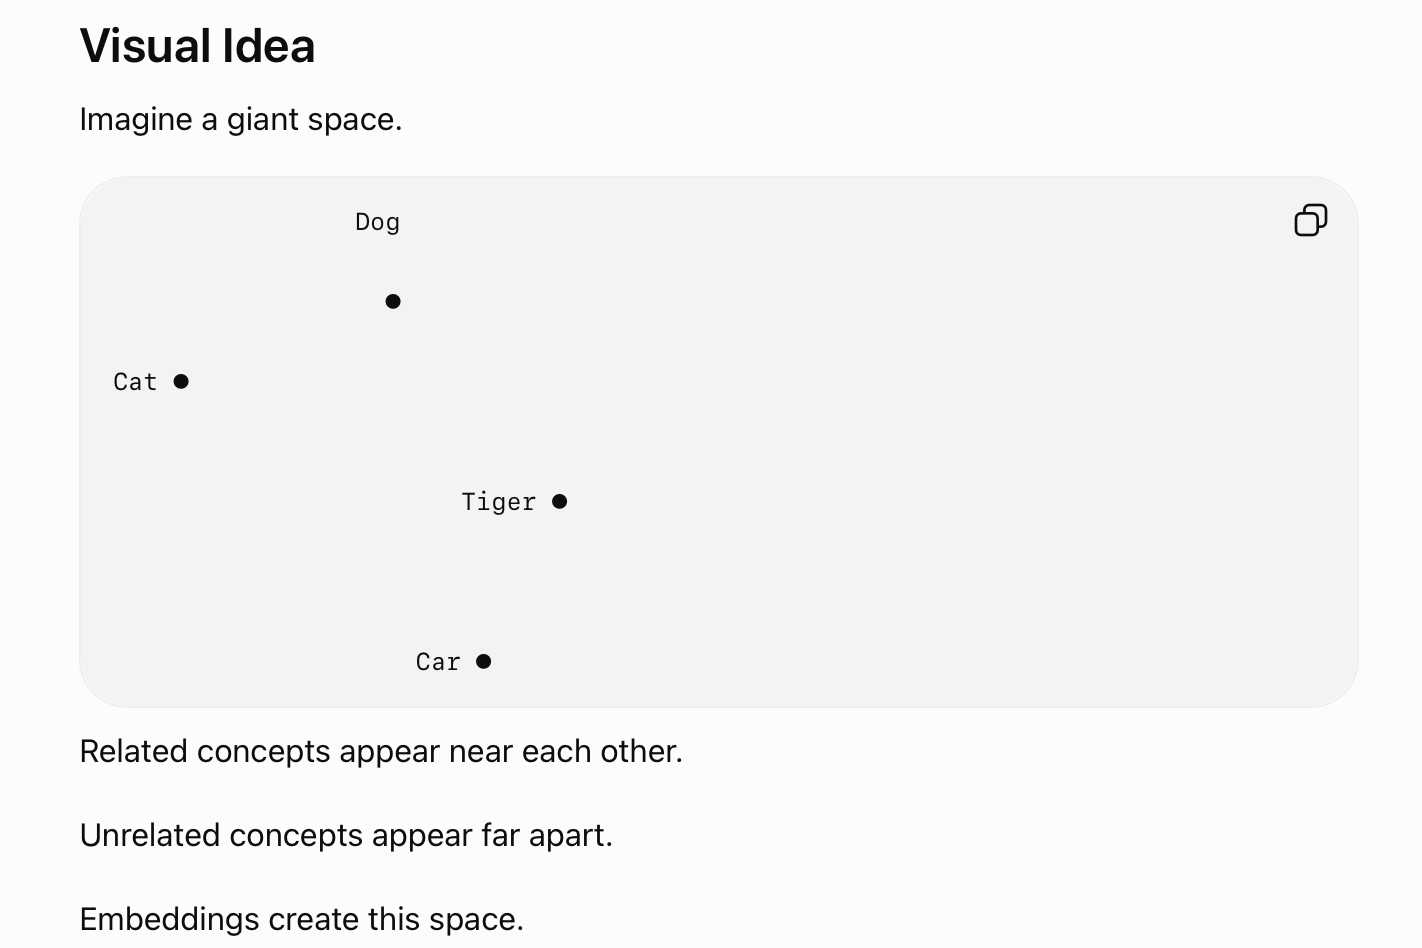

# In Langchain 
first we create an embedding model 


In [ ]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

vector = embeddings.embed_query(
    "What is Python?"
)

# RAG Flow so far :

- ` docs = loader.load() `
- ` chunks = splitter.split_documents(docs)`
-  `embeddings.embed_documents`

---
Output -> `Vector`

# 11. Vector Stores

## What is a Vector Store?

A Vector Store is a database that stores:

- Text chunks
- Their embeddings (vectors)
- Metadata

Example:

```text
Chunk:
"Python is a programming language"

Embedding:
[0.12, -0.44, 0.91, ...]

Metadata:
{
  "page": 5
}
```

---

## Why Do We Need It?

After chunking and embedding:

```text
PDF
 ↓
Chunks
 ↓
Embeddings
```

you may have thousands of vectors.

Example:

```text
Chunk 1 → [0.1, 0.2, ...]
Chunk 2 → [0.3, 0.7, ...]
Chunk 3 → [0.8, 0.4, ...]
...
Chunk 10000 → [...]
```

A Vector Store efficiently stores and searches them.

---

## Creating a Vector Store

```python
from langchain_chroma import Chroma

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings
)
```

Flow:

```text
Chunks
 ↓
Embeddings Generated
 ↓
Stored in Chroma
```

---

## Similarity Search

```python
results = vectorstore.similarity_search(
    "What is Python?"
)
```

Output:

```python
[
    Document(
        page_content="Python is a programming language..."
    )
]
```

---

## Similarity Search With Score

```python
results = vectorstore.similarity_search_with_score(
    "What is Python?"
)
```

Output:

```python
[
    (
        Document(...),
        0.92
    )
]
```

Higher score = more relevant.

---

## Mental Model

```text
Text
 ↓
Embedding Model
 ↓
Vectors
 ↓
Vector Store
 ↓
Fast Semantic Search
```

---

## Summary

A Vector Store:

- Stores embeddings
- Stores original text
- Stores metadata
- Performs similarity search

# 12. Retrievers

## What is a Retriever?

A Retriever is a search interface that finds the most relevant chunks.

```text
Question
 ↓
Retriever
 ↓
Relevant Documents
```

It does NOT answer questions.

It only fetches documents.

---

## Why Not Search Directly?

Instead of:

```python
vectorstore.similarity_search(
    "What is Python?"
)
```

LangChain provides a standard interface:

```python
retriever = vectorstore.as_retriever()
```

Now every vector database behaves the same way.

---

## Creating a Retriever

```python
retriever = vectorstore.as_retriever()
```

---

## Querying a Retriever

```python
docs = retriever.invoke(
    "What is Python?"
)
```

Output:

```python
[
    Document(
        page_content="Python is a programming language..."
    )
]
```

---

## Top-K Retrieval

Return multiple chunks.

```python
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 3}
)
```

Now:

```python
docs = retriever.invoke(
    "What is Python?"
)
```

Output:

```text
Chunk 1
Chunk 2
Chunk 3
```

Top 3 most relevant chunks.

---

## What Actually Happens?

```text
Question
 ↓
Embedding
 ↓
Vector Store Search
 ↓
Top K Chunks
 ↓
Retriever Returns Documents
```

---

## Example

Vector Store contains:

```text
Chunk 1:
Python is a programming language

Chunk 2:
Cats are animals

Chunk 3:
Neural networks learn patterns
```

User asks:

```text
Tell me about programming
```

Retriever returns:

```text
Chunk 1:
Python is a programming language
```

because it is semantically closest.

---

## Retriever ≠ LLM

Wrong:

```text
Question
 ↓
Retriever
 ↓
Answer
```

Correct:

```text
Question
 ↓
Retriever
 ↓
Relevant Chunks
```

The LLM comes later.

---

## Mental Model

```text
Vector Store
 ↓
Contains Chunks

Retriever
 ↓
Searches Chunks

Returns
 ↓
Most Relevant Documents
```

---

## Summary

Retriever:

- Searches a Vector Store
- Returns relevant documents
- Does not generate answers
- Usually returns Top-K chunks
- Is the bridge between Vector Search and RAG

PDF
 ↓
Document Loader
 ↓
Documents
 ↓
Text Splitter
 ↓
Chunks
 ↓
Embeddings
 ↓
Vectors
 ↓
Vector Store
 ↓
Retriever
 ↓
Relevant Chunks